Device: cuda
Upload Electric_Production.csv:


Saving Electric_Production.csv to Electric_Production (1).csv
Shape: (397, 2) | Range: 1985-01-01 → 2018-01-01


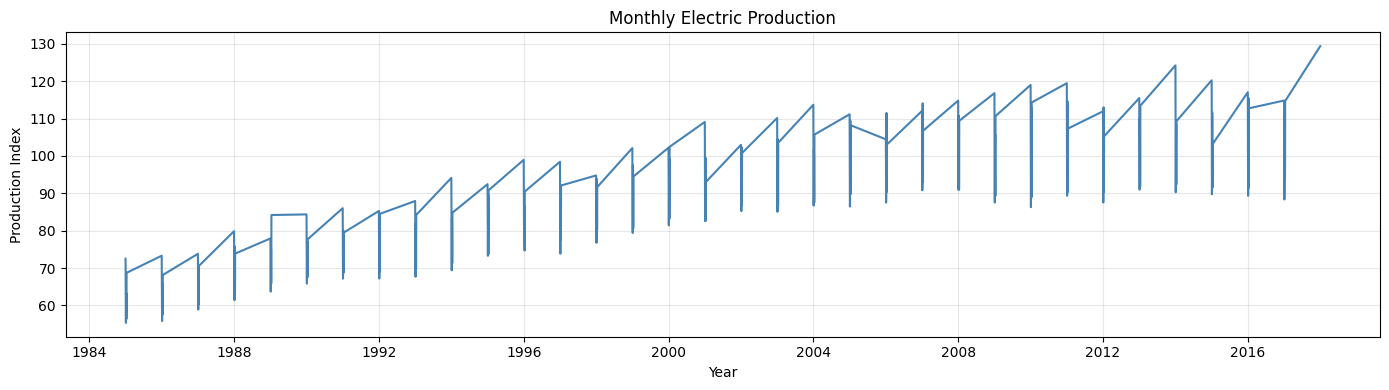


  Training RNN
[RNN] Epoch   1/200 | Train: 0.06423 | Val: 0.01023
[RNN] Epoch  25/200 | Train: 0.00164 | Val: 0.00204
[RNN] Epoch  50/200 | Train: 0.00121 | Val: 0.00189
[RNN] Epoch  75/200 | Train: 0.00134 | Val: 0.00172
[RNN] Epoch 100/200 | Train: 0.00107 | Val: 0.00173
[RNN] Epoch 125/200 | Train: 0.00105 | Val: 0.00173
[RNN] Epoch 150/200 | Train: 0.00098 | Val: 0.00170
[RNN] Epoch 175/200 | Train: 0.00094 | Val: 0.00170
[RNN] Epoch 200/200 | Train: 0.00108 | Val: 0.00169

  ✅ RNN → RMSE=4.179  MAE=2.940  R²=0.8217  MAPE=2.76%

  Training LSTM
[LSTM] Epoch   1/200 | Train: 0.04774 | Val: 0.03828
[LSTM] Epoch  25/200 | Train: 0.00560 | Val: 0.01022
[LSTM] Epoch  50/200 | Train: 0.00564 | Val: 0.00920
[LSTM] Epoch  75/200 | Train: 0.00542 | Val: 0.00940
[LSTM] Epoch 100/200 | Train: 0.00529 | Val: 0.00944
[LSTM] Epoch 125/200 | Train: 0.00534 | Val: 0.00947
[LSTM] Epoch 150/200 | Train: 0.00543 | Val: 0.00946
[LSTM] Epoch 175/200 | Train: 0.00540 | Val: 0.00946
[LSTM] Epoch 200/20

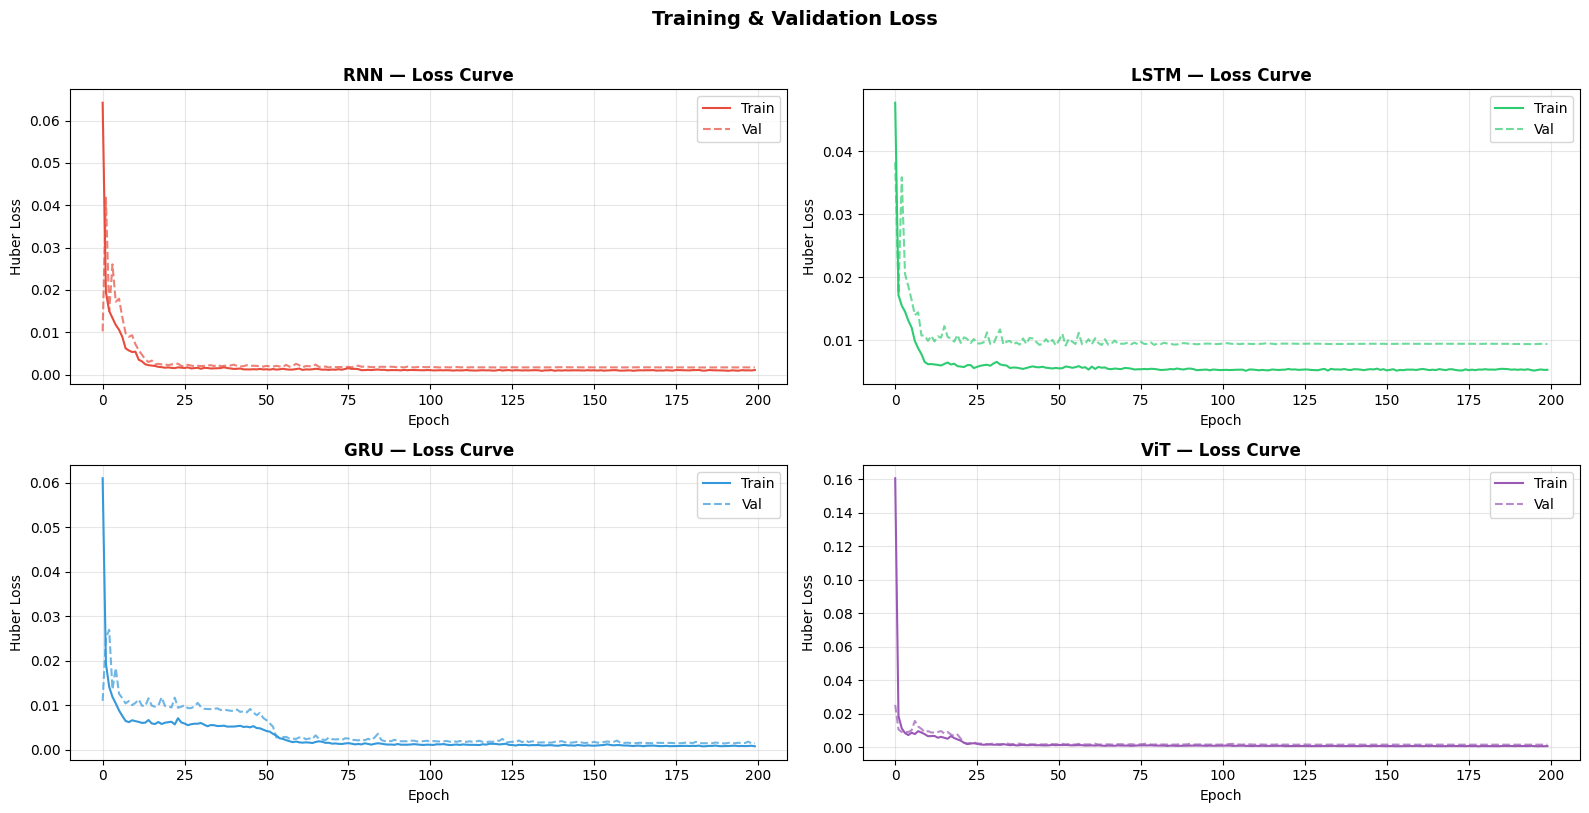

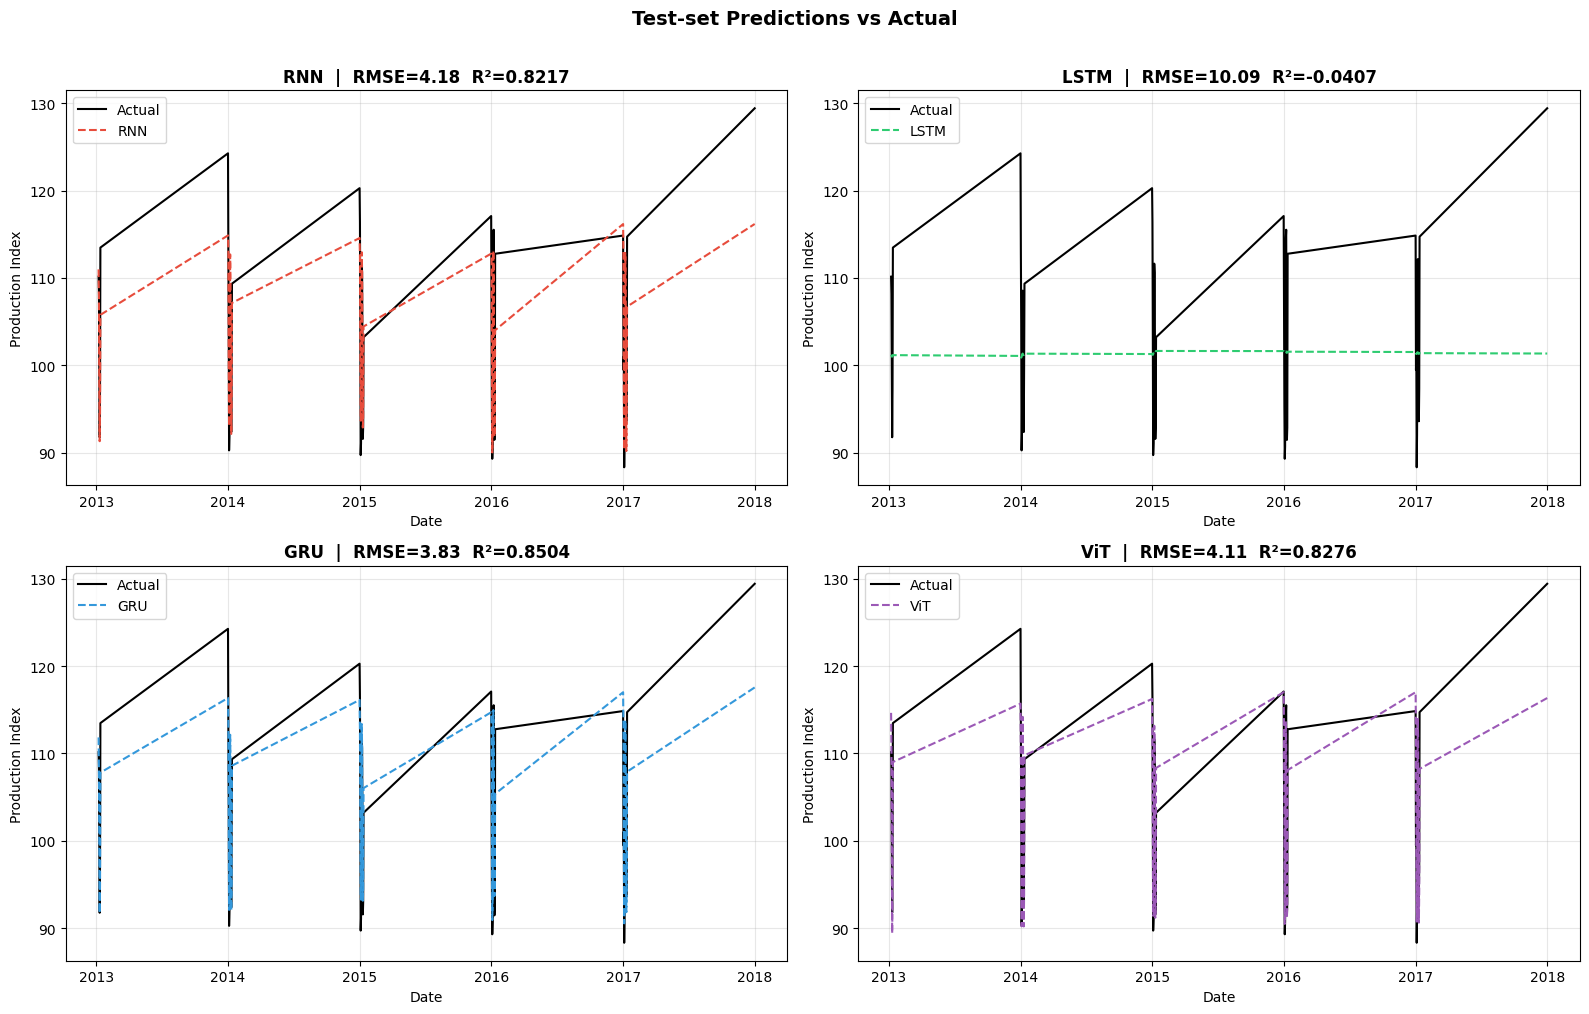

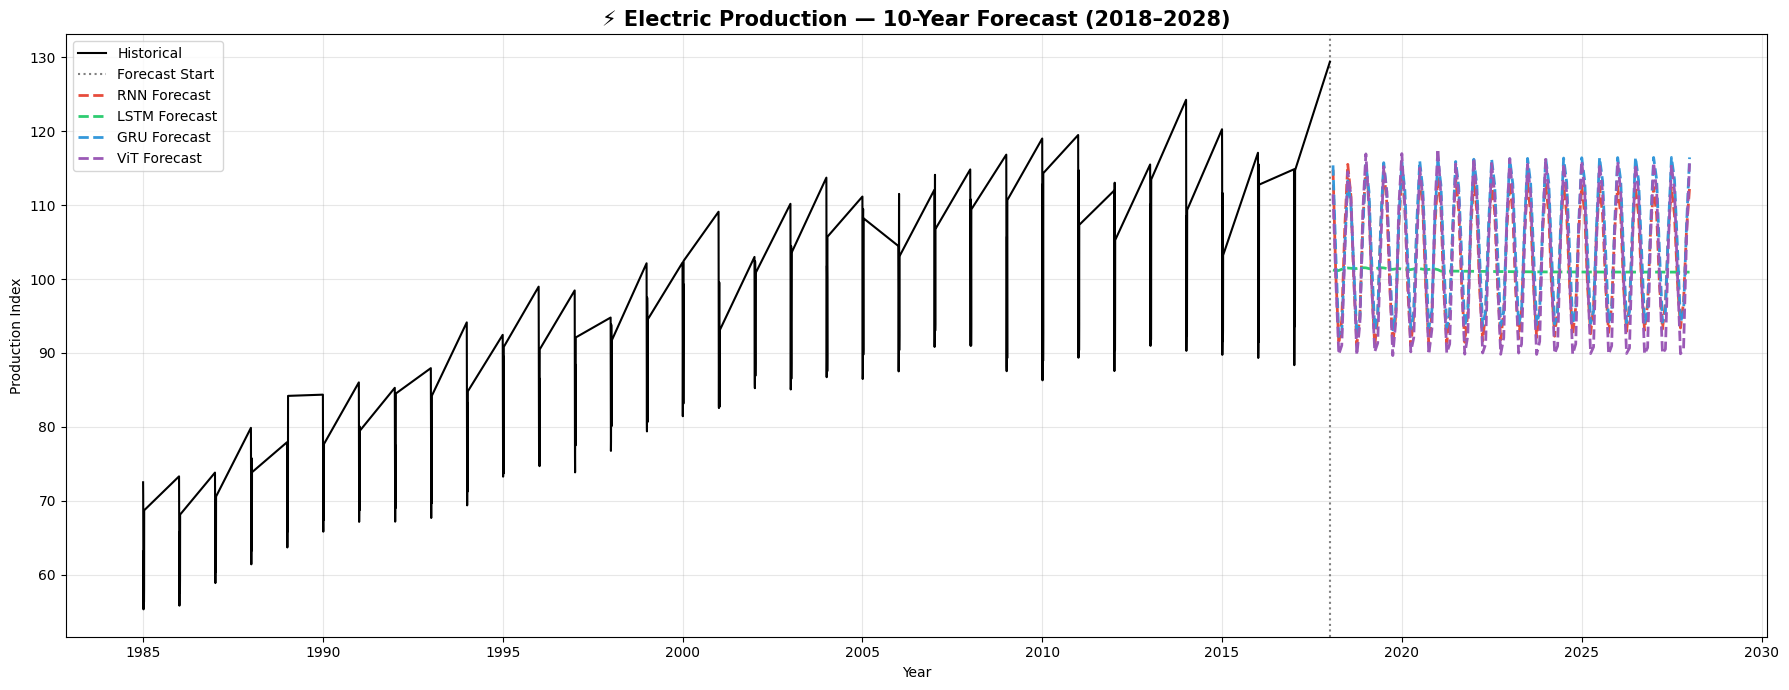

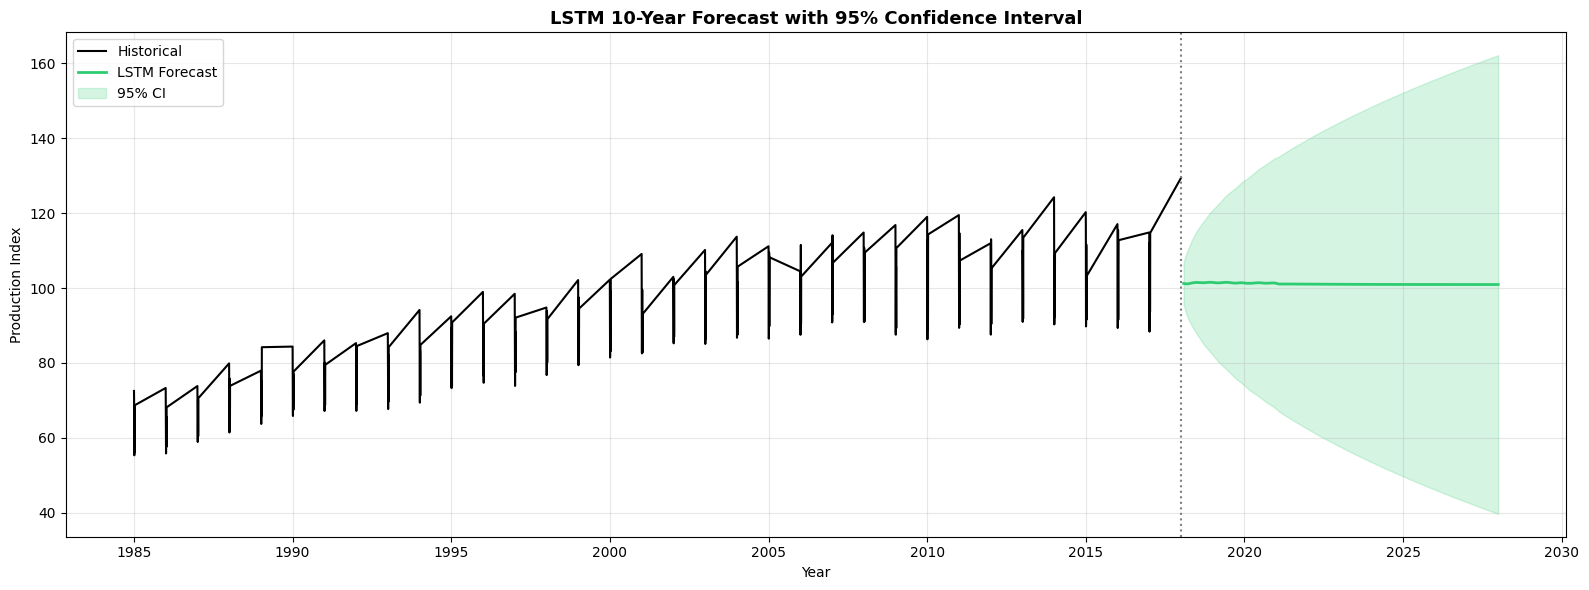

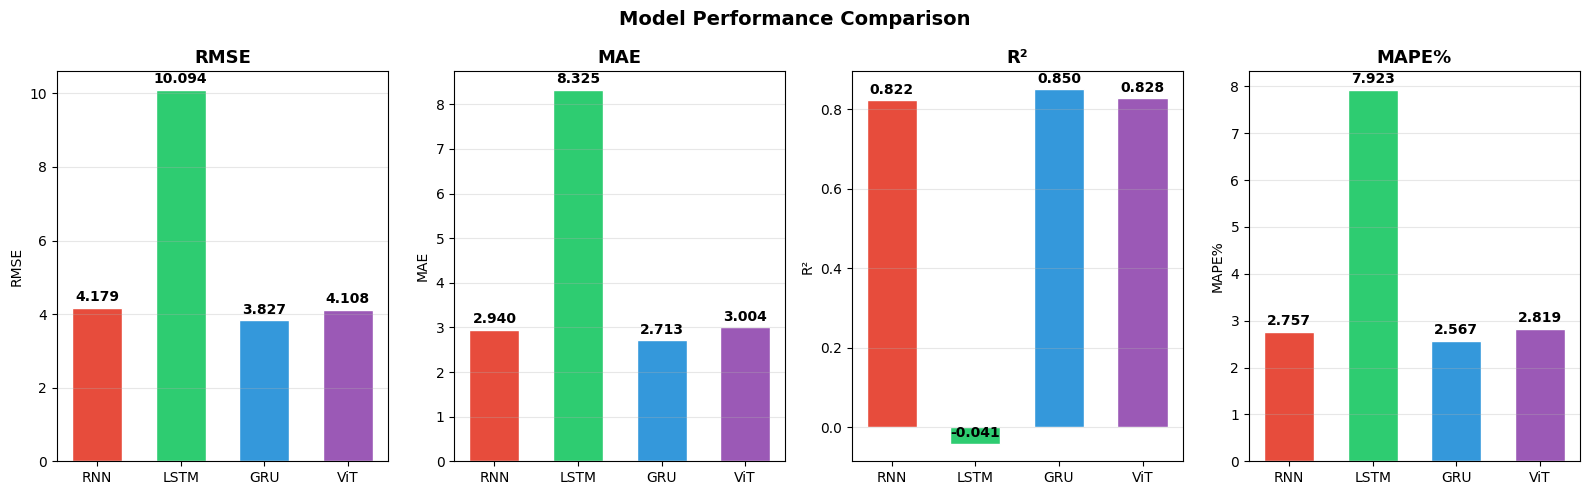


✅ Saved: electric_forecast_10years.csv
      Date  RNN_Forecast  LSTM_Forecast  GRU_Forecast  ViT_Forecast
2018-02-01    114.787872     101.230621    115.382817    111.469278
2018-03-01    100.750098     101.113109    103.556907    100.153365
2018-04-01     91.246707     101.163355     92.003446     89.813509
2018-05-01     94.464579     101.323907     92.667862     91.023403
2018-06-01    107.023021     101.455908    104.279432    103.763549
2018-07-01    115.520188     101.494032    113.295313    114.514402
2018-08-01    111.361088     101.459436    110.309922    111.409232
2018-09-01     99.587765     101.419197    101.251814    100.405947
2018-10-01     91.106756     101.427049     92.364318     89.703407
2018-11-01     95.052816     101.491753     94.606662     93.992221
2018-12-01    107.571394     101.537456    106.849986    109.263613
2019-01-01    115.427230     101.517283    115.556104    116.931650


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

!pip install -q einops


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from einops import rearrange

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import files
print("Upload Electric_Production.csv:")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df = pd.read_csv(fname)
df.columns = df.columns.str.strip()
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)
df = df.sort_values('DATE').reset_index(drop=True)
df.rename(columns={'Value': 'Production'}, inplace=True)

print(f"Shape: {df.shape} | Range: {df['DATE'].min().date()} → {df['DATE'].max().date()}")


plt.figure(figsize=(14, 4))
plt.plot(df['DATE'], df['Production'], color='steelblue')
plt.title('Monthly Electric Production')
plt.xlabel('Year'); plt.ylabel('Production Index')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


SEQ_LEN    = 36
FORECAST   = 120
BATCH_SIZE = 32
EPOCHS     = 200
LR         = 0.001
TRAIN_SPLIT = 0.85

values = df['Production'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values).flatten()

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, SEQ_LEN)
split = int(len(X) * TRAIN_SPLIT)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

def to_loader(X, y, shuffle=True):
    Xt = torch.FloatTensor(X).unsqueeze(-1)   # (N, seq, 1)
    yt = torch.FloatTensor(y).unsqueeze(-1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train)
test_loader  = to_loader(X_test,  y_test, shuffle=False)


─

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


class PatchEmbedding(nn.Module):
    def __init__(self, seq_len, patch_size, d_model):
        super().__init__()
        assert seq_len % patch_size == 0, "seq_len must be divisible by patch_size"
        self.patch_size = patch_size
        self.n_patches  = seq_len // patch_size
        self.proj = nn.Linear(patch_size, d_model)
    def forward(self, x):
        x = x.squeeze(-1)
        x = rearrange(x, 'b (n p) -> b n p', p=self.patch_size)
        return self.proj(x)

class ViT1D(nn.Module):
    def __init__(self, seq_len=24, patch_size=4, d_model=64,
                 n_heads=4, n_layers=3, mlp_dim=128, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(seq_len, patch_size, d_model)
        n_patches = seq_len // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.dropout   = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(d_model, n_heads, mlp_dim,
                                                    dropout, batch_first=True,
                                                    norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.dropout(x + self.pos_embed)
        x   = self.transformer(x)
        x   = self.norm(x[:, 0])
        return self.head(x)


def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR, name="Model"):
    model = model.to(DEVICE)
    criterion = nn.HuberLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10,
                                                     factor=0.5, min_lr=1e-5)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):

        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(train_loader)


        model.eval()
        v_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                v_loss += criterion(model(xb), yb).item()
        v_loss /= len(test_loader)

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        scheduler.step(v_loss)

        if epoch % 25 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | Train: {t_loss:.5f} | Val: {v_loss:.5f}")

    return model, train_losses, val_losses

def evaluate(model, X_test, y_test):
    model.eval()
    Xt = torch.FloatTensor(X_test).unsqueeze(-1).to(DEVICE)
    with torch.no_grad():
        preds = model(Xt).cpu().numpy()
    preds = scaler.inverse_transform(preds).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    r2   = r2_score(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100
    return preds, actual, {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE%': mape}


def forecast_future(model, last_sequence, n_steps=FORECAST):
    """Autoregressively predict n_steps into the future."""
    model.eval()
    seq = list(last_sequence)
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            inp = torch.FloatTensor(seq[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1).to(DEVICE)
            out = model(inp).item()
            preds.append(out)
            seq.append(out)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

PATCH_SIZE = 4

models_cfg = {
    'RNN':  RNNModel(),
    'LSTM': LSTMModel(),
    'GRU':  GRUModel(),
    'ViT':  ViT1D(seq_len=SEQ_LEN, patch_size=PATCH_SIZE)
}

results   = {}
histories = {}
forecasts = {}
test_preds = {}

last_seq = scaled[-SEQ_LEN:]

for mname, mdl in models_cfg.items():
    print(f"\n{'='*55}\n  Training {mname}\n{'='*55}")
    trained_mdl, t_loss, v_loss = train_model(mdl, train_loader, test_loader, name=mname)
    preds, actual, metrics = evaluate(trained_mdl, X_test, y_test)
    future = forecast_future(trained_mdl, last_seq)

    results[mname]    = metrics
    histories[mname]  = (t_loss, v_loss)
    forecasts[mname]  = future
    test_preds[mname] = preds

    print(f"\n  ✅ {mname} → RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}"
          f"  R²={metrics['R²']:.4f}  MAPE={metrics['MAPE%']:.2f}%")


# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  MODEL COMPARISON")
print("="*55)
metrics_df = pd.DataFrame(results).T.round(4)
print(metrics_df.to_string())

COLORS = {'RNN': '#E74C3C', 'LSTM': '#2ECC71', 'GRU': '#3498DB', 'ViT': '#9B59B6'}


test_dates   = df['DATE'].iloc[split + SEQ_LEN:].values
last_date    = df['DATE'].max()
future_dates = pd.date_range(last_date + pd.DateOffset(months=1),
                             periods=FORECAST, freq='MS')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
for i, (mname, (tl, vl)) in enumerate(histories.items()):
    axes[i].plot(tl, label='Train', color=COLORS[mname])
    axes[i].plot(vl, label='Val',   color=COLORS[mname], linestyle='--', alpha=0.7)
    axes[i].set_title(f'{mname} — Loss Curve', fontweight='bold')
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel('Huber Loss')
    axes[i].legend(); axes[i].grid(alpha=0.3)
plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, mname in enumerate(models_cfg):
    preds  = test_preds[mname]
    actual_vals = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    axes[i].plot(test_dates, actual_vals, label='Actual',    color='black',       linewidth=1.5)
    axes[i].plot(test_dates, preds,       label=f'{mname}',  color=COLORS[mname], linewidth=1.5, linestyle='--')
    m = results[mname]
    axes[i].set_title(f"{mname}  |  RMSE={m['RMSE']:.2f}  R²={m['R²']:.4f}", fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel('Production Index')
    axes[i].legend(); axes[i].grid(alpha=0.3)
plt.suptitle('Test-set Predictions vs Actual', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight'); plt.show()


plt.figure(figsize=(18, 7))
plt.plot(df['DATE'], df['Production'], color='black', linewidth=1.5, label='Historical', zorder=5)
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
for mname in models_cfg:
    plt.plot(future_dates, forecasts[mname], color=COLORS[mname],
             linewidth=2, linestyle='--', label=f'{mname} Forecast')
plt.title('⚡ Electric Production — 10-Year Forecast (2018–2028)', fontsize=15, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Production Index')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('10year_forecast.png', dpi=150, bbox_inches='tight'); plt.show()


lstm_fc = forecasts['LSTM']
noise   = np.std(actual_vals - test_preds['LSTM'])
ci_lo   = lstm_fc - 1.96 * noise * np.sqrt(np.arange(1, FORECAST+1)/12)
ci_hi   = lstm_fc + 1.96 * noise * np.sqrt(np.arange(1, FORECAST+1)/12)

plt.figure(figsize=(16, 6))
plt.plot(df['DATE'], df['Production'], color='black', linewidth=1.5, label='Historical')
plt.plot(future_dates, lstm_fc, color='#2ECC71', linewidth=2, label='LSTM Forecast')
plt.fill_between(future_dates, ci_lo, ci_hi, alpha=0.2, color='#2ECC71', label='95% CI')
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5)
plt.title('LSTM 10-Year Forecast with 95% Confidence Interval', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Production Index')
plt.legend(); plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('lstm_confidence.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metric_names = ['RMSE', 'MAE', 'R²', 'MAPE%']
for i, metric in enumerate(metric_names):
    vals  = [results[m][metric] for m in models_cfg]
    bars  = axes[i].bar(list(models_cfg.keys()), vals,
                        color=[COLORS[m] for m in models_cfg], edgecolor='white', width=0.6)
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_ylabel(metric)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

forecast_df = pd.DataFrame({'Date': future_dates})
for mname in models_cfg:
    forecast_df[f'{mname}_Forecast'] = forecasts[mname]

forecast_df.to_csv('electric_forecast_10years.csv', index=False)
print("\n✅ Saved: electric_forecast_10years.csv")
print(forecast_df.head(12).to_string(index=False))


files.download('electric_forecast_10years.csv')
files.download('10year_forecast.png')
files.download('metrics_comparison.png')